<a href="https://colab.research.google.com/github/silviasd2025-bit/dea_studies/blob/main/20260114_dea_dim_imp_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Jupiter DEA computes DEA VRS / CRS with configurable inputs/output

In [1]:
import subprocess
subprocess.check_call(['pip', 'install', 'pulp'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

0

In [2]:
from datetime import datetime
import os
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# The core DEA class, setting up and solving the linear programming
# problems using PuLP.



class DEAProblem:

    """
    A container for the elements of a data envelopment analysis problem. Sets
    up the linear programmes and solves them with pulp.

    Requires:

        inputs: a pandas dataframe of the inputs to the DMUs
        outputs: a pandas dataframe of the outputs from the DMUs
        kind: 'VRS' or 'CRS'
        in_weights: the weight restriction to apply to all inputs to all DMUs
                    (default is [0, inf])
        out_weights: the weight restriction to apply to all outputs to all DMUs
                     (default is [0, inf)

    Weight restrictions must be specified as a list. To specify only one bound
    leave the other as None, eg. in_weights=[1, None].

    """

    def __init__(self, inputs, outputs, returns='CRS',
                 in_weights=[0, None], out_weights=[0, None]):
        """
        Set up the DMUs' problems, ready to solve.

        """
        self.inputs = _to_dataframe(inputs)
        self.outputs = _to_dataframe(outputs)
        self.returns = returns

        self.J, self.I = self.inputs.shape  # no of firms, inputs
        _, self.R = self.outputs.shape  # no of outputs
        self._i = range(self.I)  # inputs
        self._r = range(self.R)  # outputs
        self._j = range(self.J)  # DMUs

        self._in_weights = in_weights  # input weight restrictions
        self._out_weights = out_weights  # output weight restrictions

        # creates dictionary of pulp.LpProblem objects for the DMUs
        self.dmus = self._create_problems()

    def _create_problems(self):
        """
        Iterate over the inputs and create a dictionary of LP problems, one
        for each DMU.

        """

        dmu_dict = {}
        for j0 in self._j:
            dmu_dict[j0] = self._make_problem(j0)
        return dmu_dict

    def _make_problem(self, j0):
        """
        Create a pulp.LpProblem for a DMU.

        """

        # Set up pulp
        prob = pulp.LpProblem("".join(["DMU_", str(j0)]), pulp.LpMaximize)
        self.inputWeights = pulp.LpVariable.dicts("inputWeight", (self._j, self._i),
                                                  lowBound=self._in_weights[0], upBound=self._in_weights[1])
        self.outputWeights = pulp.LpVariable.dicts("outputWeight", (self._j, self._r),
                                                   lowBound=self._out_weights[0], upBound=self._out_weights[1])

        # Set returns to scale
        if self.returns == "CRS":
            w = 0
        elif self.returns == "VRS":
            w = pulp.LpVariable.dicts("w", (self._j, self._r))
        else:
            raise Exception(ValueError)

        # Set up objective function
        prob += pulp.LpAffineExpression(
            [(self.outputWeights[j0][r1], self.outputs.values[j0][r1]) for r1 in self._r]) - w

        # Set up constraints
        prob += pulp.LpAffineExpression([(self.inputWeights[j0][i1],
                                          self.inputs.values[j0][i1]) for i1 in self._i]) == 1, "Norm_constraint"
        for j1 in self._j:
            prob += self._dmu_constraint(j0, j1) - \
                w <= 0, "".join(["DMU_constraint_", str(j1)])
        return prob

    def _dmu_constraint(self, j0, j1):
        """
        Calculate and return the DMU constraint for a single DMU's LP problem.

        """

        eOut = pulp.LpAffineExpression(
            [(self.outputWeights[j0][r1], self.outputs.values[j1][r1]) for r1 in self._r])
        eIn = pulp.LpAffineExpression(
            [(self.inputWeights[j0][i1], self.inputs.values[j1][i1]) for i1 in self._i])
        return eOut - eIn

    def _solver(self):
        """
        Iterate over the dictionary of DMUs' problems, solve them, and collate
        the results into a pandas dataframe.

        """

        sol_status = {}
        sol_weights = {}
        sol_efficiency = {}

        for ind, problem in list(self.dmus.items()):
            problem.solve()
            sol_status[ind] = pulp.LpStatus[problem.status]
            sol_weights[ind] = {}
            for v in problem.variables():
                sol_weights[ind][v.name] = v.varValue
            sol_efficiency[ind] = pulp.value(problem.objective)
        return sol_status, sol_efficiency, sol_weights

    def _build_weight_results_dict(self, sol_weights):
        """
        Rename weights from input and output column names, then build a
        pandas dataframe of all weights.

        """
        import re
        tmp_dict = {}
        for dmu, d in list(sol_weights.items()):
            tmp_dict[dmu] = {}
            for key, _ in list(d.items()):
                m = re.search(r'[0-9]+$',key)
                i = int(m.group(0))
                if key.startswith("input"):
                    tmp_dict[dmu]["in_" + str(self.inputs.columns[i])] = d[key]
                if key.startswith("output"):
                    tmp_dict[dmu][
                        "out_" + str(self.outputs.columns[i])] = d[key]
        weight_results = pd.DataFrame.from_dict(tmp_dict).T

        return weight_results

    def solve(self, sol_type='technical'):
        """"
        Solve the problem and create attributes to hold the solutions.

        Takes:
            sol_type: 'technical'/'allocative'/'economic'
            dmus: tuple defining range of DMUs to solve for.

        """

        if sol_type == 'technical':
            sol_status, sol_efficiency, sol_weights = self._solver()
            weight_results = self._build_weight_results_dict(sol_weights)
            status_df = pd.Series(sol_status, name='Status')
            status_df.index = self.inputs.index
            efficiency_df = pd.Series(sol_efficiency, name='Efficiency')
            efficiency_df.index = self.inputs.index

            return DEAResults((('Status', status_df),
                               ('Efficiency', efficiency_df),
                               ('Weights', weight_results)))
        else:
            print("Solution type not yet implemented.")
            print("Solving for technical efficiency instead.")
            self.solve()


class DEAResults(dict):

    """
    A class to hold the results of a DEAProblem and provide methods for
    their examination. Essentially a dictionary of pandas Series with
    methods for conducting particular operations on DEA results.

    """

#    def __init__(self):
#        super(DEAResults, self).__init__()
#        pass

    def find_comparators(self, dmu):
        """
        Return the DMUs that form the frontier for the specified DMU.

        """
        pass

    def env_corr(self, env_vars, qq_plot=False):
        """
        Determine correlations with environmental/non-discretionary variables
        using a logit regression. Tobit will be implemented when available
        upstream in statsmodels.

        Takes:
            env_vars: A pandas dataframe of environmental variables

        Returns:
            corr_mod: the statsmodels' model instance containing the inputs
                      and results from the logit model.

        Note that there can be no spaces in the variables' names.
        """

        import matplotlib.pyplot as plt
        from statsmodels.regression.linear_model import OLS
        from statsmodels.graphics.gofplots import qqplot

        env_data = _to_dataframe(env_vars)
        corr_data = env_data.join(self['Efficiency'])
        corr_mod = OLS.from_formula(
            "Efficiency ~ " + " + ".join(env_vars.columns), corr_data)
        corr_res = corr_mod.fit()

        #plot qq of residuals
        if qq_plot:
            qqplot(corr_res.resid, line='s')
            plt.title('Distribution of residuals')

        print(corr_res.summary())

        return corr_res


def _to_dataframe(indata):
    """
    Indexers require input to be a dataframe but the user may pass a
    series. Check and cast series to dataframes.

    """

    if type(indata) == pd.core.frame.DataFrame:
        return indata
    elif type(indata) == pd.core.series.Series:
        return pd.DataFrame(indata, columns=['input_data'])
    else:
        raise TypeError(
            "Input data is not a valid pandas DataFrame or Series.")


In [10]:
# DEA accepts : 'VRS' or 'CRS'

# Load data
df_read_old = pd.read_csv("/content/drive/MyDrive/data/20251202_owid-energy-dataDEAMPIEnergySecurityEvaluationG20.csv")
df_read_new = pd.read_csv("/content/drive/MyDrive/data/owid-energy-data G20.csv")


# Print the shape
print(df_read_new.shape)

df_new = df_read_new
df_old = df_read_old

print ("New table")
print ("==========")
print(df_new.shape)
print(df_new.columns.tolist())
list_of_variables_new_table = df_new.columns.tolist()
for elem in list_of_variables_new_table:
  print("variable(new table):", elem)

print ("Old table")
print ("==========")
print(df_old.shape)
print(df_old.columns.tolist())

list_of_variables_old_table = df_old.columns.tolist()
for elem in list_of_variables_old_table:
  print("variable(old table):", elem)

# Change name of columns 'dmu' is needed
df_new.rename(columns = {'country':'dmu'}, inplace = True)
df_old.rename(columns = {'country':'dmu'}, inplace = True)

# Replace dmu 'European Union'  by EU27
df_new['dmu'] = df_new['dmu'].replace('European Union (27)', 'EU27')
df_old['dmu'] = df_old['dmu'].replace('European Union (27)', 'EU27')

alpha_coal = 0.85
alpha_gas  = 0.90
alpha_oil  = 0.90
alpha_nuclear = 0.90
alpha_biofuel = 0.9
alpha_hydro = 0.75
alpha_solar = 0.25
alpha_wind_onshore = 0.20
alpha_wind_offshore =0.25
alpha_wind = 0.20


# Computations with columns

df_new['hhi'] = (df_new['biofuel_share_energy']**2 + df_new['coal_share_energy']**2 + df_new['gas_share_energy']**2\
             + df_new['hydro_share_energy']**2 + df_new['nuclear_share_energy']**2 + df_new['oil_share_energy']**2\
             + df_new['solar_share_energy']**2 + df_new['wind_share_energy']**2 + df_new['other_renewables_share_energy']**2)

df_new['inv_hhi'] = 1 / df_new['hhi']
#df_new['net_elec_imports_positive'] = df_new['net_elec_imports']
#df_new['net_elec_imports_positive'] = df_new['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)
df_new['gdp_per_capita'] = df_new['gdp'] / df_new['population']

df_new['net_elec_imports_positive'] = df_new['net_elec_imports_share_demand']
df_new['net_elec_imports_positive'] = df_new['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)

df_new['net_elec_export'] = df_new['net_elec_imports_share_demand']
df_new['net_elec_export'] = -df_new['net_elec_export'].where(df_new['net_elec_export'] <= 0, 0)

df_new['firm_capacity_factor'] = df_new['biofuel_elec_per_capita']/alpha_biofuel + df_new['coal_elec_per_capita']/alpha_coal\
    + df_new['gas_elec_per_capita'] / alpha_gas + df_new['hydro_elec_per_capita'] / alpha_hydro + df_new['nuclear_elec_per_capita']/alpha_nuclear\
     + df_new['oil_elec_per_capita']/ alpha_oil + df_new['solar_elec_per_capita']/ alpha_solar + df_new['wind_elec_per_capita']/  alpha_wind



df_old['net_elec_imports_positive'] = df_old['net_elec_imports_share_demand']
df_old['net_elec_imports_positive'] = df_old['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)

df_old['net_elec_export'] = df_old['net_elec_imports_share_demand']
df_old['net_elec_export'] = -df_old['net_elec_export'].where(df_new['net_elec_export'] <= 0, 0)

# Print the shape

print(df_new.shape)
countries = list(df_new['dmu'].unique())
years     = list(df_new['year'].unique())
print ('countries:', countries)
print(len(countries))

print('years:', years)
print(len(years))


list_of_variables = df_new.columns.tolist()
for elem in list_of_variables:
  print(elem)

# Create results DataFrame

df_tmp = df_new[df_new['year'] == 2000]
results = pd.DataFrame({
     'DMU': df_tmp['dmu'],
    })
l_results = []

input_cols_old = ['energy_per_capita',
                  'carbon_intensity_elec',
                  #'I3-Energy import',
                  'net_elec_imports_positive'
                  ]
output_cols_old = [
               #'Energy export',
               #'net_elec_export'
               #'MWh_capita',
               'gdp_capita',
               'per_capita_electricity'
              ]

input_cols_new = ['energy_per_capita',
              'carbon_intensity_elec',
              'net_elec_imports_positive',
              ]
output_cols_new = ['net_elec_exports_positive',
               'energy_per_capita'
               ]

#parameter
old = True
normalize = True
if old == True:
  input_cols = input_cols_old
  output_cols = output_cols_old
else:
  input_cols = input_cols_new
  output_cols = output_cols_new


variables2plot = input_cols + output_cols
year_start = 2000
year_end   = 2024
method_ret = "CRS"



(500, 130)
New table
(500, 130)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', '

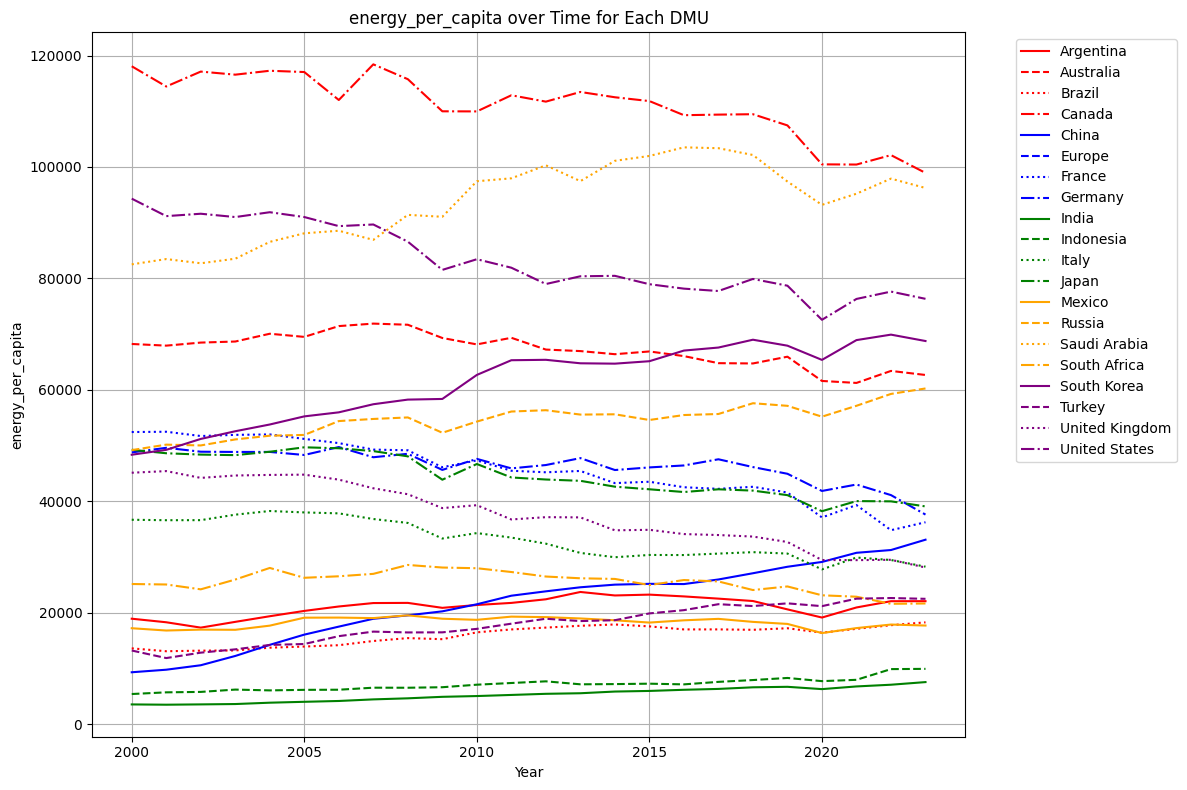

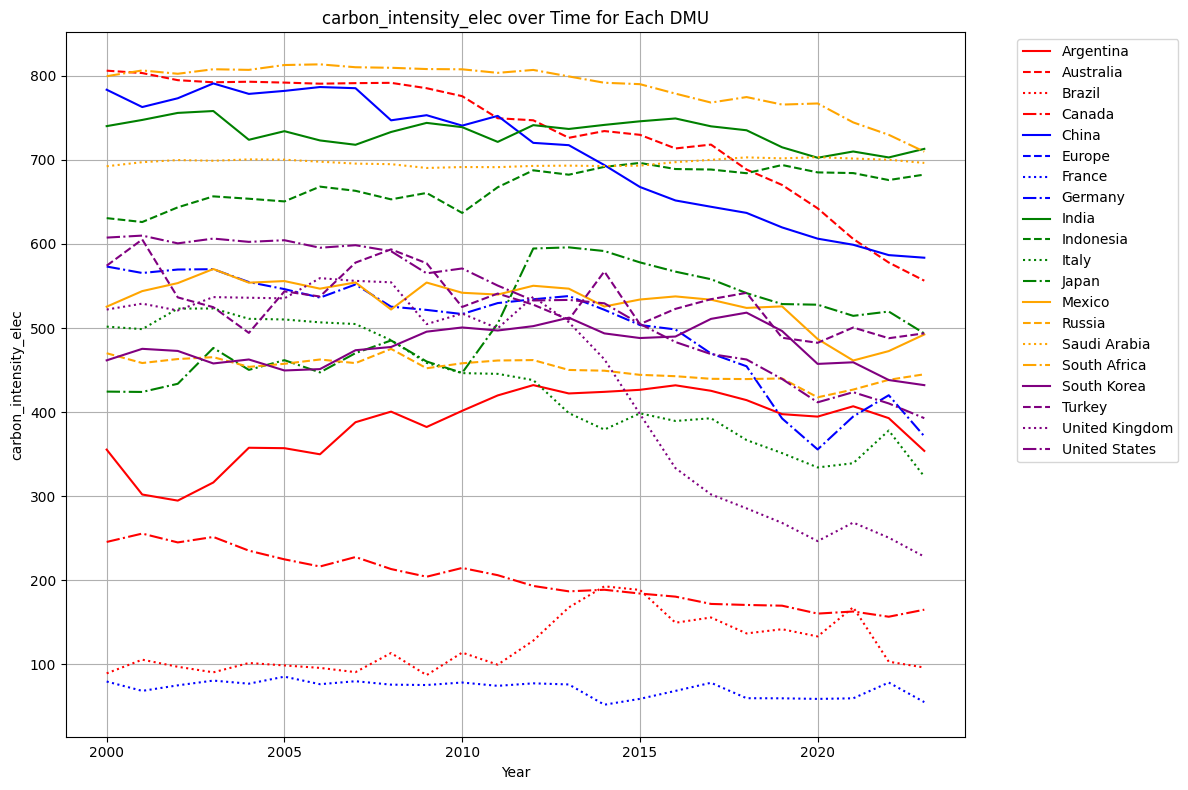

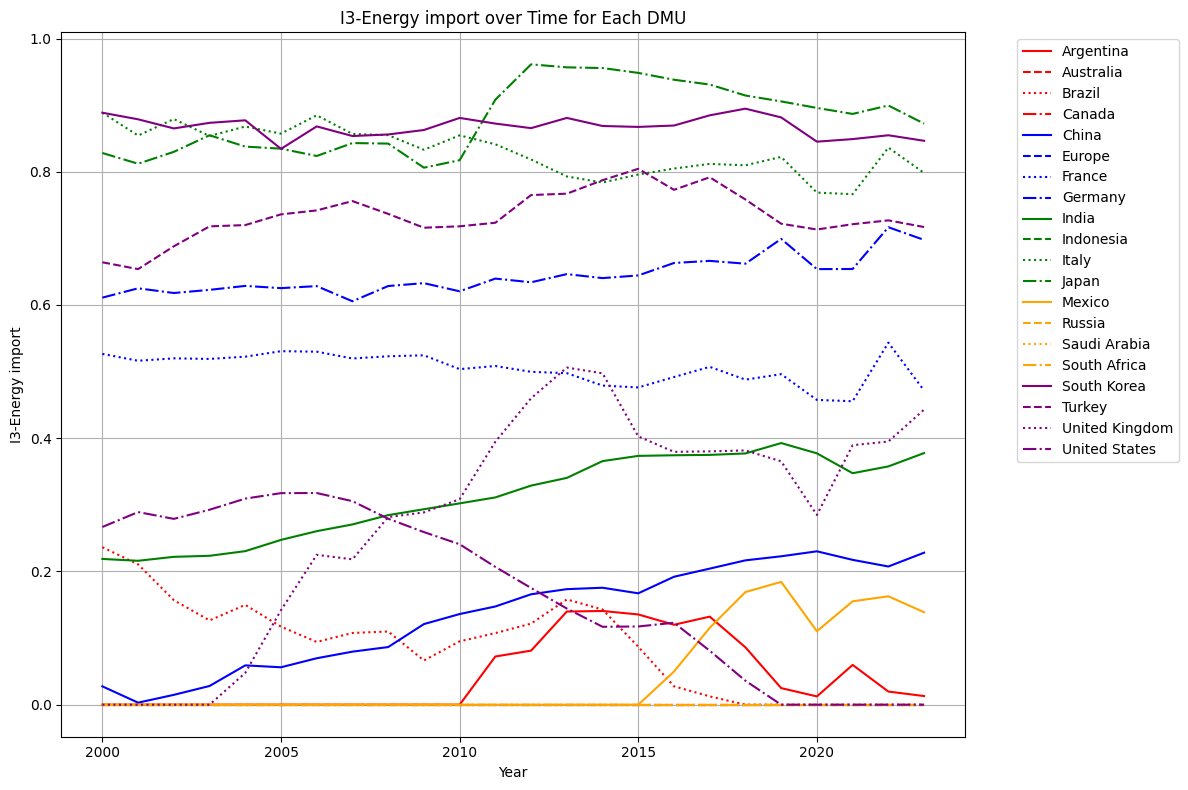

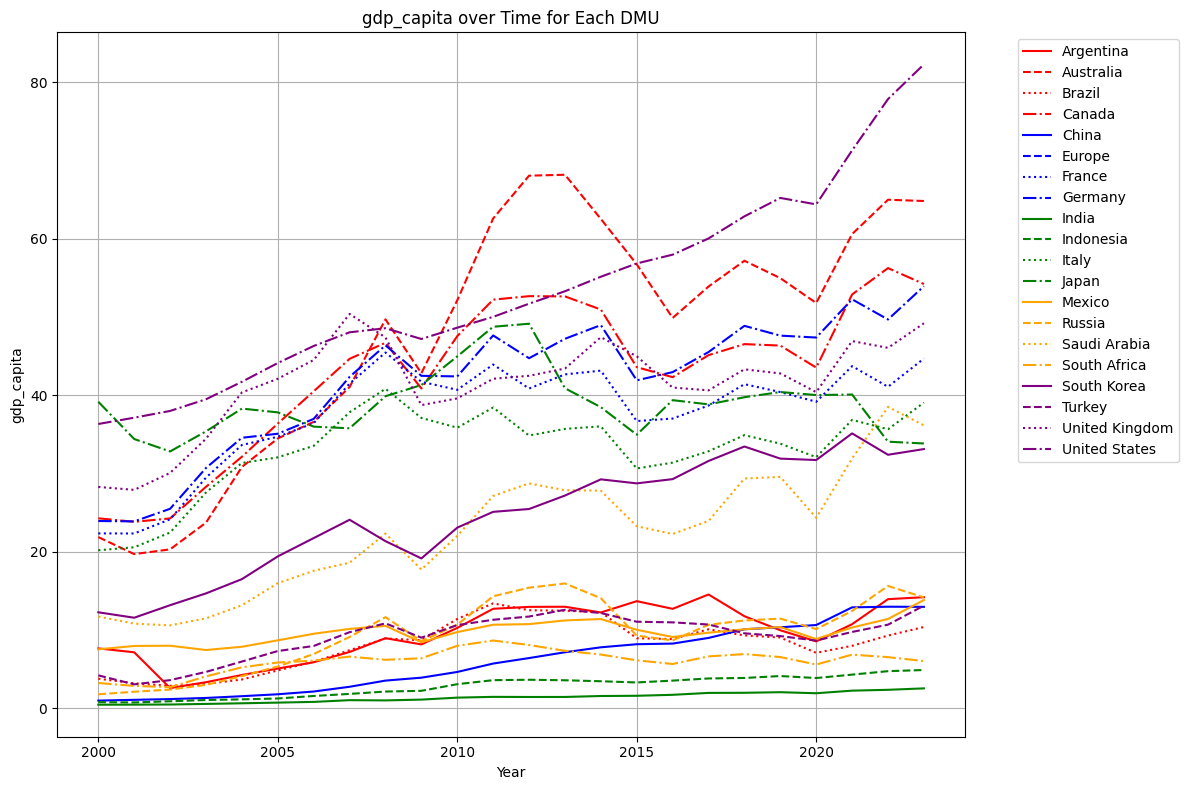

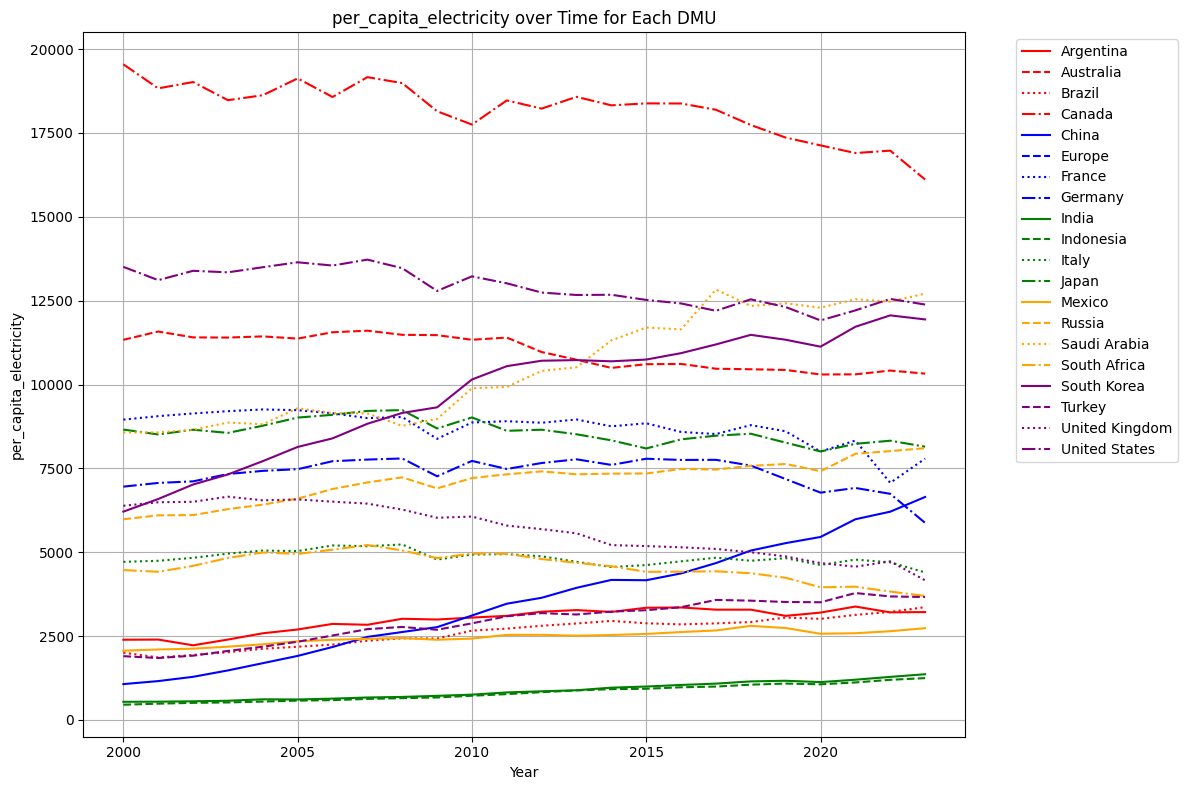

In [11]:
import itertools

# Create a list of unique colors equal to the number of DMUs
num_dmus = len(countries)
colors = plt.cm.tab20(np.linspace(0, 1, num_dmus))
color_list = [
    'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta',
    'teal', 'gold', 'navy', 'maroon', 'lime', 'coral', 'darkgrey', 'khaki', 'orchid', 'turquoise',
    'slateblue', 'darkorange'
]
# Different line styles
line_styles = ['-', '--', ':', '-.']   # solid, dashed, dotted, dash-dot

# Determine which DataFrame is currently active for plotting based on the 'old' flag.
# This part assumes 'old' variable is correctly set in previous cells.
active_df_for_plotting = df_old if old else df

# Filter variables2plot to only include columns that exist in the active_df_for_plotting.
# Also, handle specific remapping for 'old' DataFrame if needed.
adjusted_variables2plot = []
if old:
    for var in variables2plot:
        if var == 'net_elec_imports_positive':
            # Map to 'I3-Energy import' which is its equivalent in df_old
            if 'I3-Energy import' in active_df_for_plotting.columns:
                adjusted_variables2plot.append('I3-Energy import')
            else:
                print(f"Warning: 'I3-Energy import' (intended for '{var}') not found in df_old and will be skipped.")
        elif var == 'net_elec_exports':
            # This column does not have a direct equivalent in df_old and should be skipped.
            print(f"Warning: '{var}' not found in df_old and no direct equivalent for plotting; skipping.")
        elif var in active_df_for_plotting.columns:
            adjusted_variables2plot.append(var)
        else:
            print(f"Warning: Variable '{var}' not found in df_old and will be skipped.")
    variables_to_iterate = adjusted_variables2plot
else:
    # If not 'old', use the variables2plot as is, but still ensure they exist in df.
    variables_to_iterate = [var for var in variables2plot if var in active_df_for_plotting.columns]
    if len(variables_to_iterate) < len(variables2plot):
        missing_vars = set(variables2plot) - set(variables_to_iterate)
        print(f"Warning: The following variables were not found in df and will be skipped: {missing_vars}")


for variable in variables_to_iterate:
    # Create a cycle of unique (color, style) combinations
    style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)

    plt.figure(figsize=(12, 8))
    for dmu in countries:
      # 'data' will be filtered from 'active_df_for_plotting'
      data = active_df_for_plotting[active_df_for_plotting["dmu"] == dmu]

      # The variable should already be in 'variables_to_iterate' and checked for existence
      # in 'active_df_for_plotting', so direct access should be safe here.

      color, style = next(style_cycle)
      plt.plot(
            data["year"],
            data[variable],
            label=dmu,
            color=color,
            linestyle = style
        )

    plt.xlabel("Year")
    plt.ylabel(variable)
    plt.title(f"{variable} over Time for Each DMU")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
def normalize_data(data):
    """
    Normalize data using robust scaling
    """

    # Calculate min and max values for each column
    min_vals = np.min(data, axis=0)

    max_vals = np.max(data, axis=0)
    range_vals = max_vals - min_vals

    # Replace 0 values with 1 to avoid division by zero DOES NOT WORK so commment 2026/01/21
    #range_vals[range_vals == 0] = 1

    # Scale to [0.1, 1] range
    normalized = 0.1 + 0.9 * (data - min_vals) / range_vals

    return normalized

In [13]:
dir2write = datetime.now().strftime("/content/drive/MyDrive/out/%Y%m%d%H%M%S"+ method_ret)
os.mkdir(dir2write )

for year in range(year_start, year_end):
  print("------------\n\n)")
  print ("year:", year)
  print("------------\n\n)")
  if old:
    df_year     = df_old[df_old['year'] == year]
  else:
    df_year     = df_new[df_new['year'] == year]

  inputs_dea = df_year[input_cols]
  outputs_dea = df_year[output_cols]

  print("------------\n\n)")
  print ("Inputs :")
  print("------------\n\n)")
  print (inputs_dea)

  print("------------\n\n")
  print ("Outputs :")
  print("------------\n\n")
  print (outputs_dea)

  if normalize == True:
    for variable in input_cols:
      print ('variable', variable)
      print(inputs_dea[variable])
      inputs_dea[variable] = normalize_data(inputs_dea[variable])

    for variable in output_cols:
      print ('variable', variable)
      print(outputs_dea[variable])
      outputs_dea[variable] = normalize_data(outputs_dea[variable])

    print("------------\n\n")
    print ("Inputs Normalized:")
    print("------------\n\n")
    print (inputs_dea)

    print("------------\n\n")
    print ("Outputs :")
    print("------------\n\n")
    print (outputs_dea)



  prob = DEAProblem(inputs_dea, outputs_dea, returns=method_ret)
  myresults = prob.solve()

  print ('----------------\n\n\n')
  print ('*** Status ***')
  print ('----------------\n\n\n')
  print (myresults['Status'])

  print ('----------------\n\n\n')
  print ('*** Efficiency ***')
  print ('----------------\n\n\n')
  print (myresults['Efficiency'])
  l_results.append(myresults['Efficiency'])
  results[year] = myresults['Efficiency'].values

  print ('----------------\n\n\n')
  print ('----------------\n\n\n')
  print('*** Weights ***')
  print('----------------\n\n\n')

  print (type(myresults['Weights']))
  print (myresults['Weights'])


  print (results[year])
  with pd.ExcelWriter(os.path.join(dir2write,"dea_out_"+ str(year)  + '.xlsx')) as writer:
              inputs_dea.to_excel(writer, sheet_name='Inputs')
              outputs_dea.to_excel(writer, sheet_name='Outputs')
              myresults['Status'].to_excel(writer, sheet_name='Status')
              myresults['Efficiency'].to_excel(writer, sheet_name='Efficiency')
              myresults['Weights'].to_excel(writer, sheet_name='Weights')

  if  os.path.exists(os.path.join(dir2write, "dea_efficiency.xlsx")):
    with pd.ExcelWriter(os.path.join(dir2write, "dea_efficiency.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Efficiency'].to_excel(writer2eff, sheet_name=str(year))
  else:
    with pd.ExcelWriter(os.path.join(dir2write, "dea_efficiency.xlsx"), mode='w') as writer2eff:
                     myresults['Efficiency'].to_excel(writer2eff, sheet_name=str(year))

  if os.path.exists(os.path.join(dir2write, "dea_weights.xlsx")):
              with pd.ExcelWriter(os.path.join(dir2write, "dea_weights.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Weights'].to_excel(writer2eff, sheet_name=str(year))
  else:
              with pd.ExcelWriter(os.path.join(dir2write, "dea_weights.xlsx"), mode='w') as writer2eff:
                     myresults['Weights'].to_excel(writer2eff, sheet_name=str(year))

  if os.path.exists(os.path.join(dir2write, "dea_status.xlsx")):
              with pd.ExcelWriter(os.path.join(dir2write, "dea_status.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Status'].to_excel(writer2eff, sheet_name=str(year))
  else:
              with pd.ExcelWriter(os.path.join(dir2write, "dea_status.xlsx"), mode='w') as writer2eff:
                     myresults['Status'].to_excel(writer2eff, sheet_name=str(year))

------------

)
year: 2000
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  net_elec_imports_positive
0            18907.830                355.473                      1.353
24           68222.375                805.977                      0.000
48           13586.250                 89.445                     10.969
72          118073.234                245.686                     -6.308
96            9294.628                783.314                     -0.650
120          42152.680                419.096                      0.336
144          52416.219                 79.766                    -15.004
168          48756.914                573.126                      0.535
192           3521.430                740.037                      0.227
216           5387.870                630.661                      0.000
240          36668.434                501.667                     14.111
264          49228.012                42

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



0      Optimal
24     Optimal
48     Optimal
72     Optimal
96     Optimal
120    Optimal
144    Optimal
168    Optimal
192    Optimal
216    Optimal
240    Optimal
264    Optimal
288    Optimal
312    Optimal
336    Optimal
360    Optimal
384    Optimal
408    Optimal
432    Optimal
456    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



0      0.814034
24     0.957231
48     0.924602
72     0.964499
96     0.829511
120    0.858974
144    1.000000
168    0.841718
192    0.973832
216    0.816750
240    0.786101
264    1.000000
288    0.796750
312    0.743656
336    0.638750
360    1.000000
384    0.774698
408    0.895245
432    0.838498
456    0.839820
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  \
0               4.487786             

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


------------

)
year: 2002
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  net_elec_imports_positive
2            17306.420                294.834                      6.541
26           68472.781                794.666                      0.000
50           13173.614                 97.304                      9.564
74          117118.461                245.119                     -3.684
98           10553.145                773.163                     -0.510
122          42495.766                419.658                      0.261
146          51700.051                 75.212                    -16.244
170          48882.746                569.566                      1.684
194           3526.610                755.757                      0.221
218           5768.059                643.489                      0.000
242          36598.133                523.079                     15.421
266          48365.836                43

...

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


------------

)
year: 2022
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  net_elec_imports_positive
22           22049.957                392.872                      8.126
46           63386.676                577.862                      0.000
70           17744.197                103.327                      1.871
94          102122.555                156.795                     -8.408
118          31235.709                586.700                     -0.147
142          35959.199                291.706                      0.464
166          34796.070                 78.550                      3.090
190          41094.148                420.107                     -5.052
214           7057.187                702.810                     -0.095
238           9859.906                675.931                      0.239
262          29444.693                378.163                     13.303
286          39974.961                51

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


------------

)
year: 2023
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  net_elec_imports_positive
23           22053.076                353.958                      7.199
47           62658.199                556.296                      0.000
71           18252.031                 96.396                      2.084
95           98930.125                165.148                     -4.570
119          33089.070                583.608                     -0.142
143          34828.594                237.487                     -0.017
167          36221.523                 55.275                    -10.805
191          37598.512                371.311                      1.822
215           7529.441                713.013                     -0.086
239           9904.814                682.430                      0.253
263          28246.574                323.448                     16.377
287          39064.852                49

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


# New Section

In [14]:
results.head(20)
results.to_excel(os.path.join(dir2write,"dea_results.xlsx"))

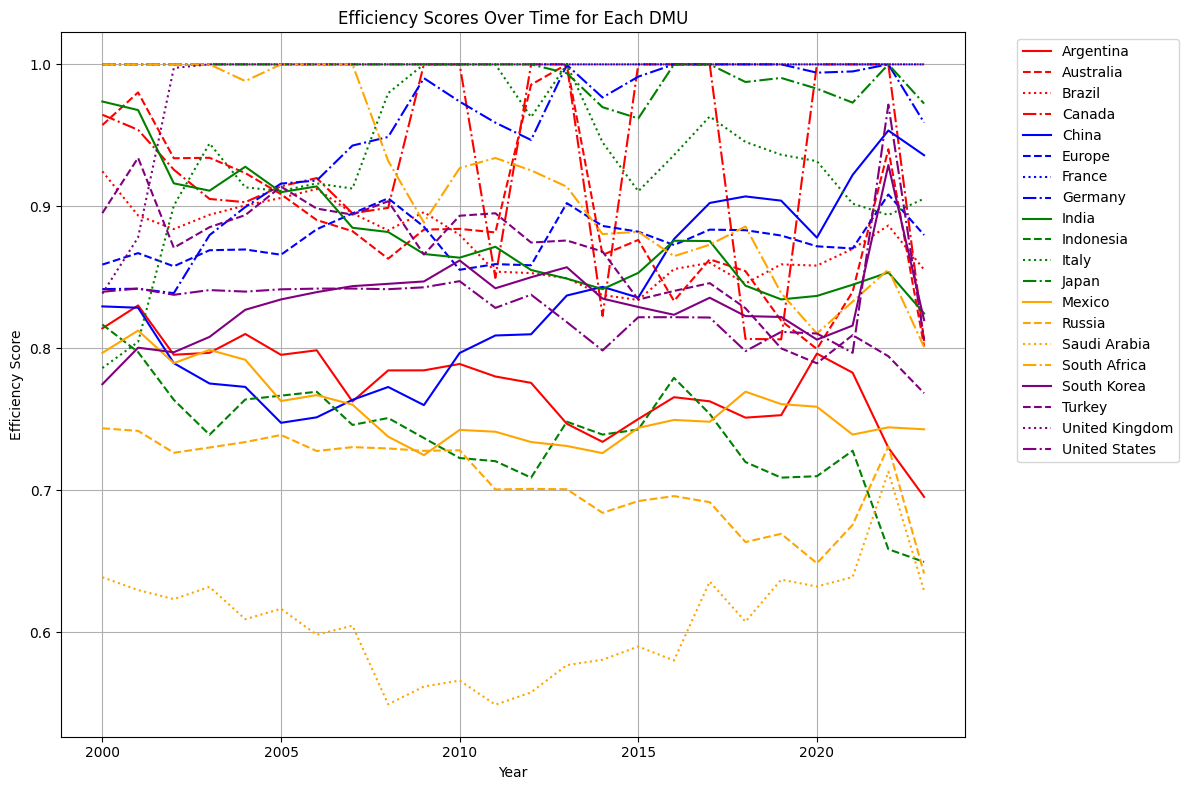

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import matplotlib.pyplot as plt

# Create a list of unique colors equal to the number of DMUs
num_dmus = len(results)
colors = plt.cm.tab20(np.linspace(0, 1, num_dmus))
color_list = [
    'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta',
    'teal', 'gold', 'navy', 'maroon', 'lime', 'coral', 'darkgrey', 'khaki', 'orchid', 'turquoise',
    'slateblue', 'darkorange'
]
# Different line styles
line_styles = ['-', '--', ':', '-.']   # solid, dashed, dotted, dash-dot

# Create a cycle of unique (color, style) combinations
style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)


# Create a cycle of unique (color, style) combinations
style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)
plt.figure(figsize=(12, 8))
for (index, row) in results.iterrows():
    color, style = next(style_cycle)
    dmu = row['DMU']
    efficiencies = row[results.columns[1:]].values
    years = results.columns[1:]  # Exclude 'DMU' column
    #print(years)
    #print (efficiencies)
    plt.plot(years, efficiencies, label=dmu, color=color, linestyle=style)

plt.xlabel('Year')
plt.ylabel('Efficiency Score')
plt.title('Efficiency Scores Over Time for Each DMU')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
print(datetime.now())

2026-01-23 13:36:46.639535


year 2000
results[year]
0      0.814034
25     0.957231
50     0.924602
75     0.964499
100    0.829511
125    0.858974
150    1.000000
175    0.841718
200    0.973832
225    0.816750
250    0.786101
275    1.000000
300    0.796750
325    0.743656
350    0.638750
375    1.000000
400    0.774698
425    0.895245
450    0.838498
475    0.839820
Name: 2000, dtype: float64
range
range(0, 20)
results[DMU]
0           Argentina
25          Australia
50             Brazil
75             Canada
100             China
125            Europe
150            France
175           Germany
200             India
225         Indonesia
250             Italy
275             Japan
300            Mexico
325            Russia
350      Saudi Arabia
375      South Africa
400       South Korea
425            Turkey
450    United Kingdom
475     United States
Name: DMU, dtype: object
year 2001
results[year]
0      0.830187
25     0.980235
50     0.893549
75     0.953861
100    0.828577
125    0.867036
150    1.000

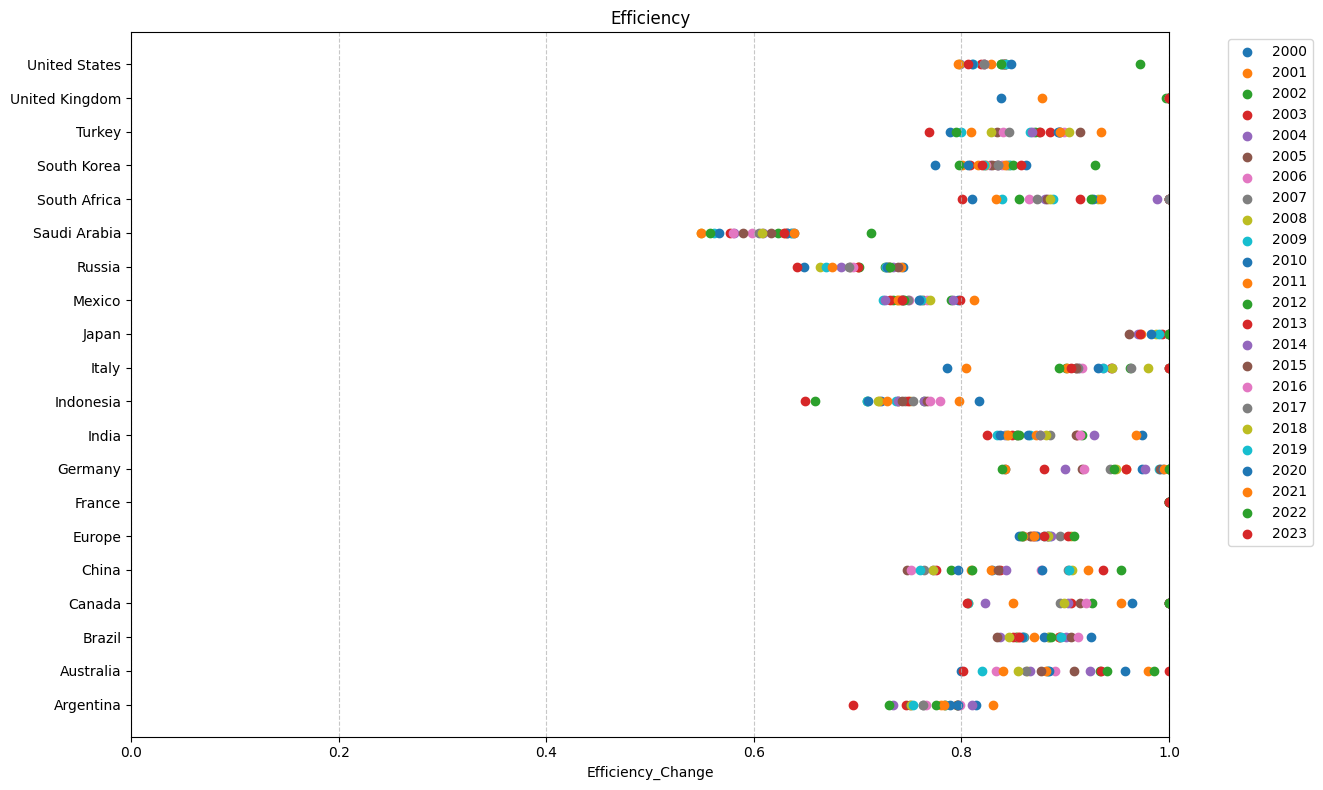

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

for year in range(year_start,year_end):

  print ("year", year)
  # Create the figure and ax  is

  # Plot the mean EC points
  print("results[year]")
  print (results[year])
  print("range")
  print(range(len(results)))

  print ("results[DMU]")
  print (results['DMU'])

  ax.scatter(results[year], range(len(results)), label=str(year))

  # Plot the confidence intervals
  #for idx, row in df4.iterrows():
  #    ax.hlines(y=df4.index.get_loc(idx),
  #              xmin=row['Eff_CI_Lower'],
  #              xmax=row['Eff_CI_Upper'],
  #              color='blue',
  #              alpha=0.3)

#Customize the plot
ax.set_yticks(range(len(results)))
ax.set_yticklabels(results['DMU'])
ax.set_xlabel('Efficiency_Change')
ax.set_title('Efficiency')

# Add a grid for better readability
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.set_xlim(0,1)
# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(dir2write,"efficiency_plot.png"))
plt.show()